# Exploración inicial de datos : 

In [296]:
import pandas as pd
# Importar el CSV
df_consumo = pd.read_csv('consumo_energetico.csv')
# Mostrar informacip
print(df_consumo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   area_vivienda_m2          286 non-null    float64
 1   habitantes                286 non-null    int64  
 2   temperatura_promedio      286 non-null    float64
 3   electrodomesticos         276 non-null    float64
 4   horas_aire_acondicionado  286 non-null    float64
 5   antiguedad_vivienda       286 non-null    int64  
 6   horas_iluminacion         286 non-null    float64
 7   consumo_mensual_kwh       286 non-null    float64
 8   consumo_historico_kwh     0 non-null      float64
 9   codigo_sensor             286 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 22.5 KB
None


In [297]:
# --- INSPECCIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS ---

# Mostrar cuántos valores faltantes hay por cada columna, (tambies se puede deducir de .info())
print("--- Valores nulos por columna ---")
print(df_consumo.isna().sum())

# Eliminar columna de consumo_historico_kwh (porque tiene todos sus dato vacios)
df_consumo.drop("consumo_historico_kwh", axis=1, inplace=True)

# Eliminar filas con valores vacios de electrodomesticos (dado que son pocos valores, se opto por eliminarlos. De hecho, da una mejor valor de R^2 eliminandolos que rellenandolos con el promedio) :
df_consumo.dropna(subset=['electrodomesticos'], inplace=True)

# Contar si hay sensores con código repetido
conteos = df_consumo['codigo_sensor'].value_counts()
valores_repetidos = conteos[conteos > 1].index.tolist()

print(f'Valores repetidos : {valores_repetidos}')

# Eliminar los sensores con código repetido (porque se detecto que solo se repite uno)
df_consumo.drop_duplicates(subset=['codigo_sensor'], keep=False, inplace=True)


# Modifica el DataFrame original eliminando las filas con valores negativos
df_consumo.drop(df_consumo[df_consumo['area_vivienda_m2'] < 0].index, inplace=True)
df_consumo.drop(df_consumo[df_consumo['habitantes'] < 0].index, inplace=True)
df_consumo.drop(df_consumo[df_consumo['consumo_mensual_kwh'] < 0].index, inplace=True)



--- Valores nulos por columna ---
area_vivienda_m2              0
habitantes                    0
temperatura_promedio          0
electrodomesticos            10
horas_aire_acondicionado      0
antiguedad_vivienda           0
horas_iluminacion             0
consumo_mensual_kwh           0
consumo_historico_kwh       286
codigo_sensor                 0
dtype: int64
Valores repetidos : [792603]


# 1. MODELO DE MÍNIMOS CUADRADOS ORDINARIO (OLS) (Con Statsmodels)

In [298]:
import statsmodels.api as sm

# 1. Definir variables predictoras (X) y variable respuesta (y)
X = df_consumo[['area_vivienda_m2','habitantes', 'temperatura_promedio','electrodomesticos','horas_aire_acondicionado','antiguedad_vivienda','horas_iluminacion']]
y = df_consumo['consumo_mensual_kwh']

# 2. statsmodels exige añadir explícitamente una constante para calcular beta_0 (el intercepto)
X_con_constante = sm.add_constant(X)
print("--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---")
display(X_con_constante)

# 3. Ajustamos el modelo usando Mínimos Cuadrados Ordinarios (OLS)
modelo_sm = sm.OLS(y, X_con_constante).fit()

# 4. Mostramos el resumen estadístico
print(modelo_sm.summary())


--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---


,const,area_vivienda_m2,habitantes,temperatura_promedio,electrodomesticos,horas_aire_acondicionado,antiguedad_vivienda,horas_iluminacion
0,1.0,109.207037,1,25.800171,18.0,7.330210,15,3.999229
1,1.0,85.178151,4,24.324206,19.0,9.807910,27,4.505261
2,1.0,127.789267,4,26.815253,17.0,9.169392,13,10.903745
3,1.0,119.669128,6,23.975762,19.0,8.378231,12,9.474599
4,1.0,156.242693,6,23.279238,12.0,3.523274,28,6.808261
...,...,...,...,...,...,...,...,...
280,1.0,115.842143,1,26.874774,16.0,7.023894,5,9.409893
281,1.0,149.989382,4,28.544990,17.0,0.692400,22,10.621697
282,1.0,82.579609,3,21.188016,11.0,6.243166,26,7.563253
283,1.0,127.067810,5,25.319325,11.0,5.170333,9,3.947402


                             OLS Regression Results                            
Dep. Variable:     consumo_mensual_kwh   R-squared:                       0.979
Model:                             OLS   Adj. R-squared:                  0.979
Method:                  Least Squares   F-statistic:                     1679.
Date:                 Sat, 16 May 2026   Prob (F-statistic):          6.20e-205
Time:                         16:14:32   Log-Likelihood:                -1176.2
No. Observations:                  256   AIC:                             2368.
Df Residuals:                      248   BIC:                             2397.
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

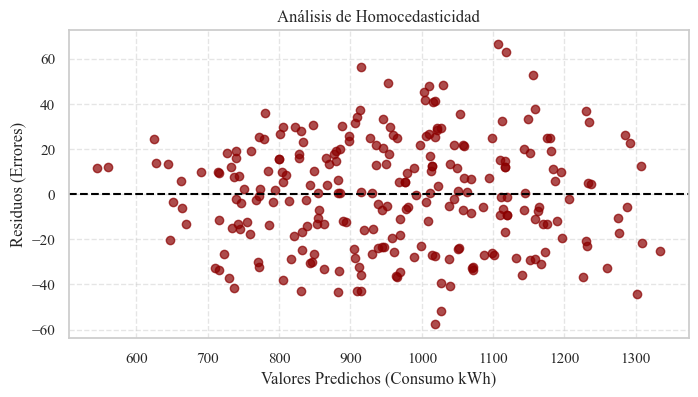

In [299]:
# --- EVALUACIÓN DE RESIDUOS ---
import matplotlib.pyplot as plt

# Calculamos las predicciones del modelo
predicciones = modelo_sm.predict(X_con_constante)
# El residuo es la diferencia entre el valor real y el valor predicho
residuos = y - predicciones

# Gráfica de Residuos vs Predicciones
plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="darkred")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos (Consumo kWh)')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()


Como los puntos están dispersos sin un patrón claro formando una banda horizontal, hay homocedasticidad.

In [300]:
# ---  PROPONER AQUÍ UN CÓDIGO PARA EVALUAR SI LOS ERRORES SE DISTRIBUYEN DE FORMA NORMAL"
from scipy import stats
stat, p = stats.normaltest(residuos)
print(f"Se aproxima a distribución normal : p = {p}" if p > 0.05 else f"No se aproxima a distribución normal : p = {p}")

Se aproxima a distribución normal : p = 0.05267329677825559


In [301]:
import numpy as np 
# Prueba de distribución normal: 

from scipy.stats import skew, kurtosis
m_media = np.mean(residuos)
m_varianza = np.var(residuos)
m_asimetria = skew(residuos) # Calcula el sesgo estandarizado
m_curtosis = kurtosis(residuos) # Calcula la curtosis estandarizada

print(f"  - Media      (1er): {m_media:.4f}")
print(f"  - Varianza   (2do): {m_varianza:.4f}")
print(f"  - Sesgo  (3er): {m_asimetria:.4f}")
print(f"  - Curtosis   (4to): {m_curtosis:.4f}\n")

  - Media      (1er): -0.0000
  - Varianza   (2do): 573.1227
  - Sesgo  (3er): 0.0850
  - Curtosis   (4to): -0.5563



Dado que tanto el sesgo como la Curtosis toman valores cercanos a cero, se asume que la dstribución tiende a ser normal 

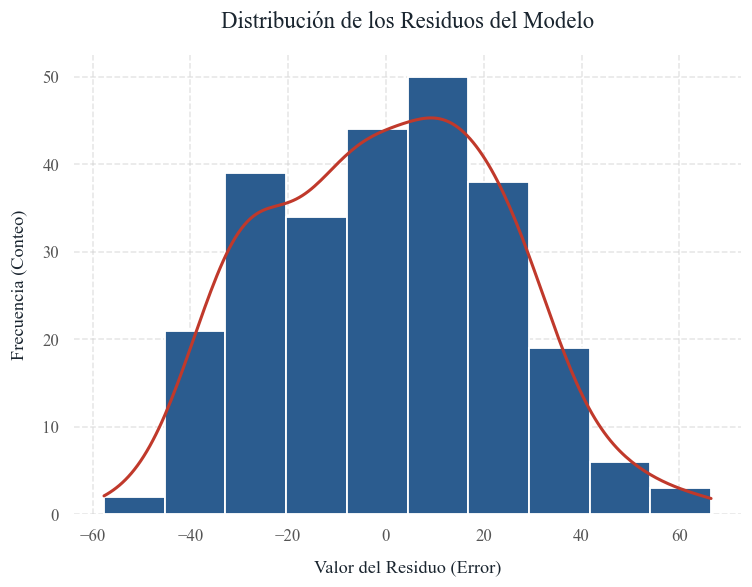

In [309]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5, "font.family": "serif"})

# Crear la figura 
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=110)

# 3. Histograma con colores sólidos (sin transparencia)
sns.histplot(
    residuos, 
    kde=True,                  # Añade la curva de suavizado
    color='#2b5c8f',           # Azul elegante corporativo sólido
    edgecolor='white',         # Borde blanco entre barras
    linewidth=1.2,
    alpha=1.0,                 # Opaco / Sin colores translúcidos
    bins=10,                   
    ax=ax
)

# Ajustar el color de la línea KDE para que contraste con las barras sólidas
if ax.lines:
    ax.lines[0].set_color('#c0392b')  # Línea de densidad en un tono rojizo sólido
    ax.lines[0].set_linewidth(2)

# 4. Título centrado en Times New Roman
plt.title(
    "Distribución de los Residuos del Modelo", 
    fontsize=15, pad=18, color='#1a252f', loc='center'
)

# 5. Formatear y espaciar los ejes
ax.set_xlabel("Valor del Residuo (Error)", fontsize=12, labelpad=10, color='#1a252f')
ax.set_ylabel("Frecuencia (Conteo)", fontsize=12, labelpad=10, color='#1a252f')

# Limpiar bordes innecesarios y aplicar tipografía a los números de los ejes
sns.despine(left=True, bottom=True)
ax.tick_params(colors='#555555', labelsize=11)

# Ajuste y visualización
plt.tight_layout()
plt.show()


In [303]:
print(df_consumo.head(5))

# Estimación con el modelo de regresión lineal : 

# Crear un DataFrame con los valores específicos que quieres evaluar
nuevos_datos = pd.DataFrame([{
    'area_vivienda_m2': 109,
    'habitantes': 1,
    'temperatura_promedio': 26,
    'electrodomesticos': 18,
    'horas_aire_acondicionado': 7,
    'antiguedad_vivienda': 15,
    'horas_iluminacion': 4
}])

# Añadir la constante para que coincida con la estructura del modelo
# statsmodels añadirá una columna llamada 'const' con el valor 1.0 al inicio
nuevos_datos_con_constante = sm.add_constant(nuevos_datos, has_constant='add')

# Hacer la predicción
prediccion = modelo_sm.predict(nuevos_datos_con_constante)

print("El consumo mensual estimado es:", prediccion[0], "kWh")

   area_vivienda_m2  habitantes  temperatura_promedio  electrodomesticos  \
0        109.207037           1             25.800171               18.0   
1         85.178151           4             24.324206               19.0   
2        127.789267           4             26.815253               17.0   
3        119.669128           6             23.975762               19.0   
4        156.242693           6             23.279238               12.0   

   horas_aire_acondicionado  antiguedad_vivienda  horas_iluminacion  \
0                  7.330210                   15           3.999229   
1                  9.807910                   27           4.505261   
2                  9.169392                   13          10.903745   
3                  8.378231                   12           9.474599   
4                  3.523274                   28           6.808261   

   consumo_mensual_kwh  codigo_sensor  
0              1028.78         234374  
1              1130.61         54149

# 2. MODELO DE MINIMOS CUDARADOS (con scikit-learn)

In [304]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_consumo[['area_vivienda_m2', 'habitantes', 'temperatura_promedio','electrodomesticos','horas_aire_acondicionado','antiguedad_vivienda', 'horas_iluminacion']]
y = df_consumo['consumo_mensual_kwh']

# Instanciamos el modelo y ajustamos modelo
modelo_ml = LinearRegression()
modelo_ml.fit(X, y)

print("Intercepto (Beta_0):", modelo_ml.intercept_)
print("Variables:", X.columns)
print("Coeficientes (Betas):", modelo_ml.coef_)

Intercepto (Beta_0): 23.398061183107075
Variables: Index(['area_vivienda_m2', 'habitantes', 'temperatura_promedio',
       'electrodomesticos', 'horas_aire_acondicionado', 'antiguedad_vivienda',
       'horas_iluminacion'],
      dtype='object')
Coeficientes (Betas): [ 3.38206828 39.21384784 -0.12395746 25.42242579 17.74412819 -0.13006443
 -0.62752977]


In [305]:
# Calculamos las métricas de error y precisión
predicciones = modelo_ml.predict(X)
mse = mean_squared_error(y, predicciones)
r2 = r2_score(y, predicciones)

print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")


Error Cuadrático Medio (MSE): 573.12
Coeficiente de Determinación (R^2): 0.9793


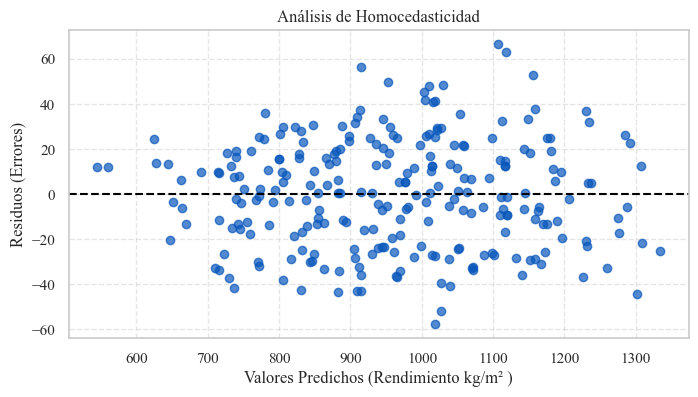

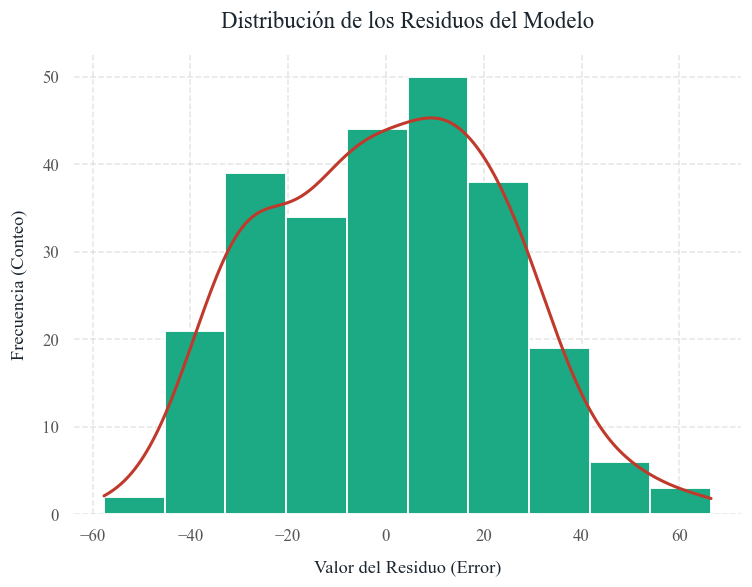

Estadístico: 5.887293308703562
p-value: 0.052673296778256974
Los datos parecen seguir una distribución normal


In [312]:
# --- EVALUACIÓN DE RESIDUOS ---

# El residuo es la diferencia entre el valor real y el valor predicho
residuos = y - predicciones

# Gráfica de Residuos vs Predicciones
plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="#0957bc")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos (Rendimiento kg/m² )')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5, "font.family": "serif"})

# Crear la figura 
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=110)

# 3. Histograma con colores sólidos (sin transparencia)
sns.histplot(
    residuos, 
    kde=True,                  # Añade la curva de suavizado
    color='#1baa84',           # Azul elegante corporativo sólido
    edgecolor='white',         # Borde blanco entre barras
    linewidth=1.2,
    alpha=1.0,                 # Opaco / Sin colores translúcidos
    bins=10,                   
    ax=ax
)

# Ajustar el color de la línea KDE para que contraste con las barras sólidas
if ax.lines:
    ax.lines[0].set_color('#c0392b')  # Línea de densidad en un tono rojizo sólido
    ax.lines[0].set_linewidth(2)

# 4. Título centrado en Times New Roman
plt.title(
    "Distribución de los Residuos del Modelo", 
    fontsize=15, pad=18, color='#1a252f', loc='center'
)

# 5. Formatear y espaciar los ejes
ax.set_xlabel("Valor del Residuo (Error)", fontsize=12, labelpad=10, color='#1a252f')
ax.set_ylabel("Frecuencia (Conteo)", fontsize=12, labelpad=10, color='#1a252f')

# Limpiar bordes innecesarios y aplicar tipografía a los números de los ejes
sns.despine(left=True, bottom=True)
ax.tick_params(colors='#555555', labelsize=11)

# Ajuste y visualización
plt.tight_layout()
plt.show()

# EVALUAR SI LOS ERRORES SE DISTRIBUYEN DE FORMA NORMAL"
from scipy import stats
stat, p = stats.normaltest(residuos)

print("Estadístico:", stat)
print("p-value:", p)
if p > 0.05:
    print("Los datos parecen seguir una distribución normal")
else:
    print("Los datos NO siguen una distribución normal")

In [307]:
# Estimación con el modelo de regresión lineal :

nuevos_datos = pd.DataFrame([{
    'area_vivienda_m2': 109,
    'habitantes': 1,
    'temperatura_promedio': 26,
    'electrodomesticos': 18,
    'horas_aire_acondicionado': 7,
    'antiguedad_vivienda': 15,
    'horas_iluminacion': 4
}])

prediccion = modelo_ml.predict(nuevos_datos)

print("El consumo mensual estimado es:", prediccion[0], "kWh")

El consumo mensual estimado es: 1005.3859339990051 kWh


habitantes 3, temperatura 26, electrodomesticos 10, horas aire 5, antiguedad 15, horas ilumunacion 6, area 120